## Disaster tweets classification.

Dataset was sourced from kaggle - https://www.kaggle.com/competitions/nlp-getting-started
This python script builds and trains a series of models to predict if a disaster occurred based on X (Twitter) tweets

The dataset is also available on Github: https://github.com/laxmimerit/twitter-disaster-prediction-dataset/tree/master

This python script is a work in progress


In [1]:
# Import Libraries
import re
import string
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

plt.style.use('ggplot')

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout, Flatten
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

pd.set_option('display.max_colwidth', None)

## Read in the data

In [2]:
# Below is a function to read in and create dataframes for the train and test data from my local drive.
# I have kept this code in but chose to not run it.
# I am obtaining the data from github, however, in case that data becomes unavailable, the below function is available to read in from my local drive where I have saved it
def load_from_drive():
    
    # Set the location to read the files
    base_path = "C:\\Users\\User\\Documents\\Python_Repositories\\NLP_Projects\\Disaster_Tweets\\"
    training_path = base_path + "train.csv"
    test_path = base_path + "test.csv"

    # Read in the train and test datasets and save these as dataframes
    tweet = pd.read_csv(training_path)
    tweet_test = pd.read_csv(test_path)

In [3]:
tweet = pd.read_csv('https://raw.githubusercontent.com/laxmimerit/twitter-disaster-prediction-dataset/refs/heads/master/train.csv')
tweet.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


In [4]:
# Check the number of rows and columns
tweet.shape

(7613, 5)

In [5]:
# Check null values
# some observations for keyword and location are missing
tweet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


## Exploratory data analysis

In [6]:
# Set default parameters for plots
plt.rcParams['figure.figsize'] = [8,4]
plt.rcParams['figure.dpi'] = 120

Target class distribution - check number of times the target was 1 (disaster) and 0 (not a disaster)

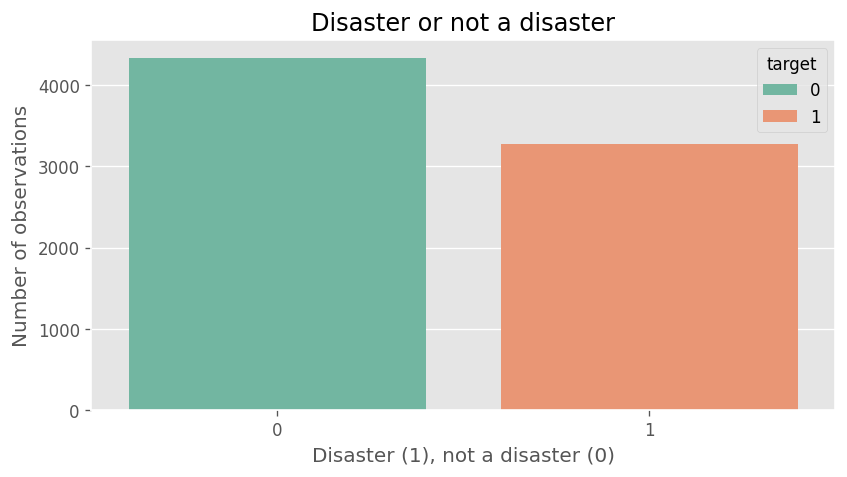

In [7]:
sns.countplot(data=tweet, x = 'target', hue = 'target', palette = "Set2")
plt.title('Disaster or not a disaster')
plt.xlabel('Disaster (1), not a disaster (0)')
plt.ylabel('Number of observations')
plt.show()

In [8]:
# Check the actual number of observations for each of the target variable
tweet['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

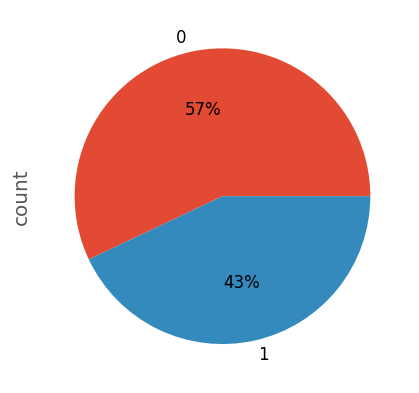

In [9]:
# Create a pie plot to check the proportion of observations in each target. Display as a percentage
tweet['target'].value_counts().plot.pie(autopct = '%1.f%%')
plt.show()

### Number of characters in a tweet. Distribution in the number of characters

In [10]:
# Install pre-process package from git.
# This is available here: https://github.com/laxmimerit/preprocess_kgptalkie
!pip install git+https://github.com/laxmimerit/preprocess_kgptalkie.git

  Cloning https://github.com/laxmimerit/preprocess_kgptalkie.git to c:\users\user\appdata\local\temp\pip-req-build-zc0q3c8_
  Resolved https://github.com/laxmimerit/preprocess_kgptalkie.git to commit 0f56a6502679f6750b7f0ffed98f590d1f0246bd
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/laxmimerit/preprocess_kgptalkie.git 'C:\Users\User\AppData\Local\Temp\pip-req-build-zc0q3c8_'


In [11]:
import preprocess_kgptalkie as kgp

C:\Users\User\anaconda3\envs\tflowenv\lib\site-packages\torch\__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ..\torch\csrc\tensor\python_tensor.cpp:433.)
  _C._set_default_tensor_type(t)


Create a feature for the number of characters in the tweet

In [12]:
# Create a feature for character length
tweet['char_count'] = tweet['text'].apply(lambda x: len(x))

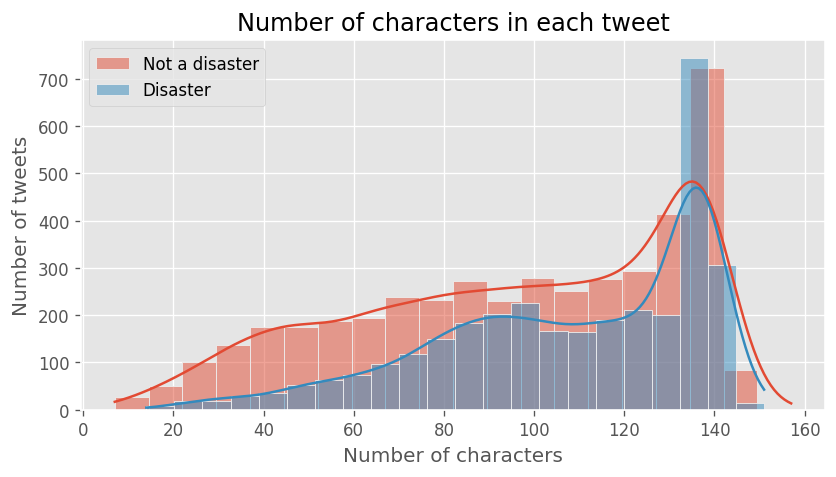

In [13]:
# plot the distribution of characters in each tweet
tweet0 = tweet[tweet['target']==0]
tweet1 = tweet[tweet['target']==1]
sns.histplot(tweet0['char_count'], kde=True, label = "Not a disaster")
sns.histplot(tweet1['char_count'], kde=True, label = "Disaster")
plt.title('Number of characters in each tweet')
plt.xlabel('Number of characters')
plt.ylabel('Number of tweets')
plt.legend()
plt.show()

In [14]:
tweet

,id,keyword,location,text,target,char_count
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,69
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1,133
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1,65
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,88
...,...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse into nearby homes http://t.co/STfMbbZFB5,1,83
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control wild fires in California even in the Northern part of the state. Very troubling.,1,125
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. http://t.co/zDtoyd8EbJ,1,65
7611,10872,NaN,NaN,Police investigating after an e-bike collided with a car in Little Portugal. E-bike rider suffered serious non-life threatening injuries.,1,137


[]

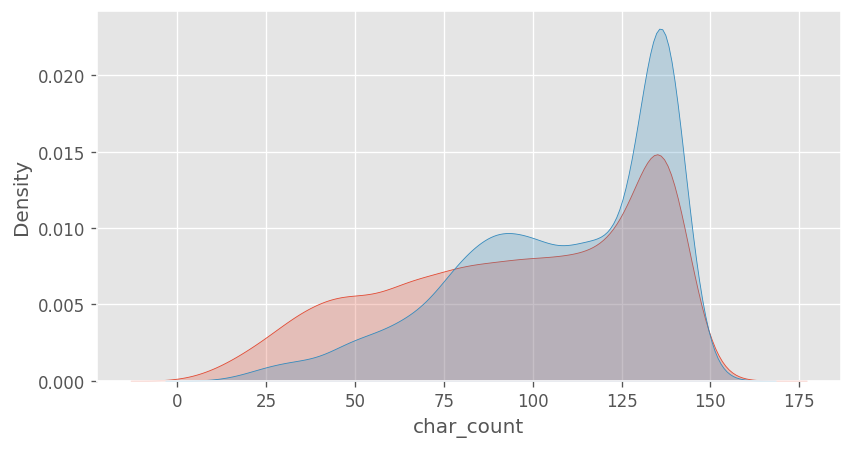

In [15]:
sns.kdeplot(tweet[tweet['target']==0]['char_count'], fill = True)
sns.kdeplot(tweet[tweet['target']==1]['char_count'], fill = True)
plt.plot()

### Number of words in a tweet

In [16]:
# Create a feature for the number of words
tweet['word_count'] = tweet['text'].apply(lambda x:  len(x.split(" ")))

[]

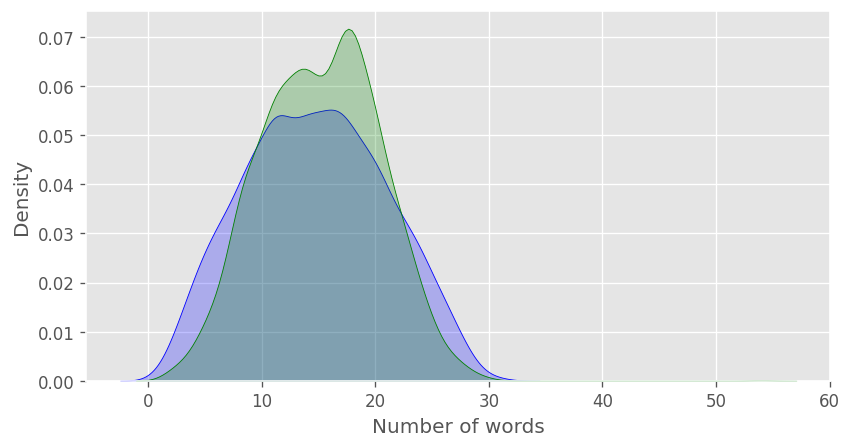

In [17]:
# KDE plot for the number of words in each tweet
sns.kdeplot(tweet[tweet['target']==0]['word_count'], fill = True, color = 'blue')
sns.kdeplot(tweet[tweet['target']==1]['word_count'], fill = True, color = 'green')
plt.xlabel('Number of words')
plt.plot()

### Average word length for each tweet

In [19]:
# Create a function to compute the average length of each word in each tweet
def avg_word_length(text):

    # Split the tweet into a list
    text = word_tokenize(text)

    # initiate an expty list to store the lengths of each word in the tweet list
    count = [] 
    for i in text:
        count.append(len(i))

    # Return the average word length as the sum of all word lengths divided by the number of words for each tweet
    return sum(count)/len(count)

In [20]:
# Create a feature for the number of words
tweet['avg_word_length'] = tweet['text'].apply(lambda x: avg_word_length(x))

[]

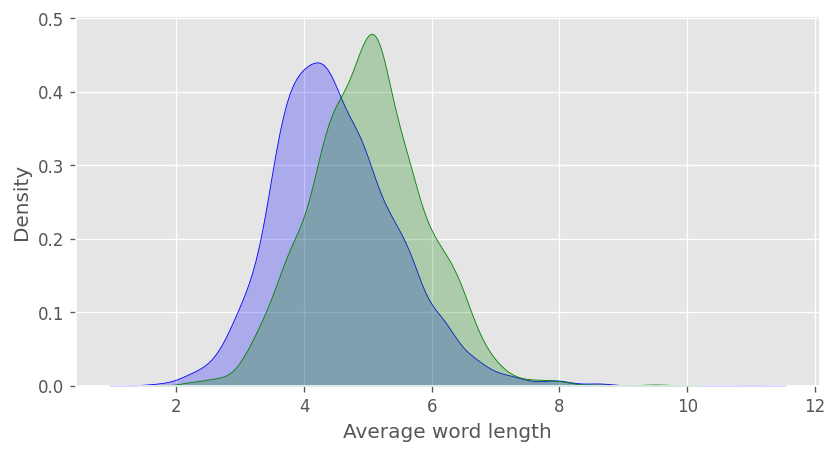

In [21]:
# KDE plot for the average word length of each tweet
sns.kdeplot(tweet[tweet['target']==0]['avg_word_length'], fill = True, color = 'blue')
sns.kdeplot(tweet[tweet['target']==1]['avg_word_length'], fill = True, color = 'green')
plt.xlabel('Average word length')
plt.plot()

### stop words count

In [22]:
# Create a function to count the number of stop words
stop_words = stopwords.words('english')
def stop_words_count(text):

    # Initialise a counter for the number of stop words
    count = 0
    
    # Tokenise to split the tweets into a list
    text = word_tokenize(text)
    
    # Loop[ through all of the words in each tweet and count the number that are stop words
    for word in text:
        if word in stop_words:
            count+=1
    return count

In [23]:
# Create a column for the number of stop words in each tweet
tweet['stop_word_count'] = tweet['text'].apply(lambda x: stop_words_count(x))

[]

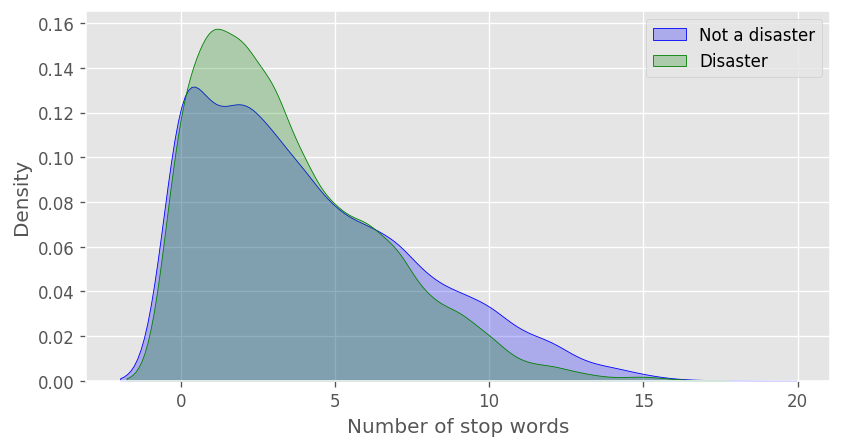

In [24]:
# KDE plot for the number of stop words in each tweet
sns.kdeplot(tweet[tweet['target']==0]['stop_word_count'], fill = True, color = 'blue', label = "Not a disaster")
sns.kdeplot(tweet[tweet['target']==1]['stop_word_count'], fill = True, color = 'green', label = "Disaster")
plt.xlabel('Number of stop words')
plt.legend()
plt.plot()

## Text Pre-Processing

In [25]:
# Create a function to convert the tweet to lower case and replce \\, _, . with a space
def lower_case(tweet):
    results = []
    for i in tweet['text']:
        i = str(i).lower().replace('\\',' ').replace('_',' ').replace('.',' ')
        results.append(i)
    tweet['text'] = results
    return tweet

In [26]:
# Create a function to remove email addresses from the tweet
def remove_email(tweet):
    results = []
    for i in tweet['text']:
        i = re.sub(r'\S*@\S*\s?', "", i)
        results.append(i)
    tweet['text'] = results
    return tweet

In [27]:
# Create a function to remove urls from the tweet
def remove_url(tweet):
    results = []
    for i in tweet['text']:
        i = re.sub(r'(https|http)?:\/\/(\w|\.|\/|\?|\=|\&|\%)*\b', "", i)
        results.append(i)
    tweet['text'] = results
    return tweet

In [28]:
# Create a function to remove duplicate letters from the tweet
def remove_dup_char(tweet):
    results = []
    for i in tweet['text']:
        i = re.sub("([a-zA-Z])\\1{2,}", "\\1", i)
        results.append(i)
    tweet['text'] = results
    return tweet

In [29]:
# Create a function to remove special characters from the tweet
def remove_special(tweet):
    results = []
    for i in tweet['text']:
        # Replace anything that is not a letter, number of space with blank
        i = re.sub('[^A-Za-z0-9 ]+', '', i)
        results.append(i)
    tweet['text'] = results
    return tweet

In [30]:
tweet = (tweet
         .pipe(lower_case)
         .pipe(remove_email)
         .pipe(remove_url)
         .pipe(remove_dup_char)
         .pipe(remove_special)
        )

In [31]:
tweet.head()

,id,keyword,location,text,target,char_count,word_count,avg_word_length,stop_word_count
0,1,NaN,NaN,our deeds are the reason of this earthquake may allah forgive us all,1,69,13,4.071429,5
1,4,NaN,NaN,forest fire near la ronge sask canada,1,38,7,4.000000,0
2,5,NaN,NaN,all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place orders are expected,1,133,22,4.666667,9
3,6,NaN,NaN,13000 people receive wildfires evacuation orders in california,1,65,9,6.333333,1
4,7,NaN,NaN,just got sent this photo from ruby alaska as smoke from wildfires pours into a school,1,88,17,4.000000,6


## Word Cloud

### Most frequent words for disaster tweets

In [32]:
# Compute frequency of each word in the tweets
wordfreq = tweet[tweet['target']==1]['text'].str.split(expand=True).stack().value_counts()

In [33]:
# Convert the text from the word frequencies into a string
wordfreq_df = pd.DataFrame(wordfreq)
disaster_freq = ' '.join(wordfreq_df.index)

(-0.5, 799.5, 499.5, -0.5)

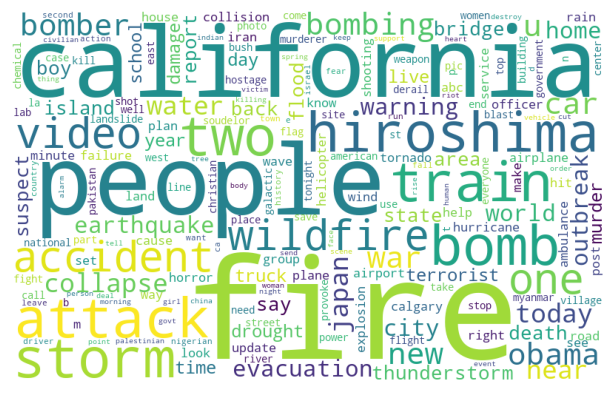

In [34]:
# Create a wordcloud
wc = WordCloud(background_color='white', colormap = 'viridis', width = 800, height = 500).generate(disaster_freq)
plt.imshow(wc)
plt.axis("off")

## Classification using TFIDF

In [35]:
# Create x and y variables.
text = tweet['text']
y = tweet['target']

In [36]:
# Instantiate TFIDF and fit and transform to the text data
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(text)

In [37]:
X.shape

(7613, 20297)

### Train Test Split
Since I am reading in the data from Github, I need to perform train test split.
On my local drive, train and test datasets are already available, however, I am not using these

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

### ML code

In [39]:
# Instantiate an svm with a linear kernel. 
clf_svm = svm.SVC(kernel='linear')

# Fit the model to the train x vectors and the y labels
clf_svm.fit(X_train, y_train)

# Predict on the test data
y_pred = clf_svm.predict(X_test)

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.91      0.85      1086
           1       0.85      0.70      0.77       818

    accuracy                           0.82      1904
   macro avg       0.82      0.80      0.81      1904
weighted avg       0.82      0.82      0.81      1904



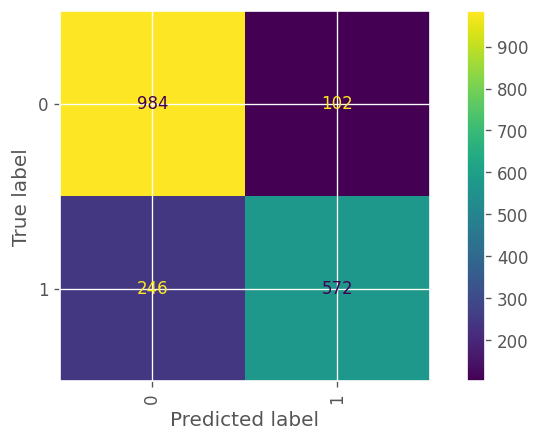

In [41]:
# Display the confusion matrix
categories = [0, 1]
conf_matrix = confusion_matrix(y_test, y_pred, labels = categories)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=categories)

# Plot the confusion matrix
disp.plot()
plt.xticks(rotation=90)
plt.show()

## Classification with word2vec and SVM

In [42]:
# Download the large spacy model
#!python -m spacy download en_core_web_lg

In [43]:
import spacy
import en_core_web_lg

In [44]:
# Instantiate the model
nlp = spacy.load("en_core_web_lg")

In [45]:
# Create word vector representations for each tweet
def get_vec(x):
    doc = nlp(x)
    vec = doc.vector
    return vec

In [46]:
tweet['vec'] = tweet['text'].apply(lambda x: get_vec(x))

In [47]:
# Convert the vectorised text to a numpy array and reshape
X = tweet['vec'].to_numpy()
X = X.reshape(-1,1)

In [48]:
X = np.concatenate(np.concatenate(X, axis=0), axis=0).reshape(-1,300)

In [49]:
X.shape

(7613, 300)

In [50]:
# y variable as the target
y = tweet['target']

### Train Test Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [52]:
# Instantiate an svm with a linear kernel. 
clf = svm.SVC(kernel='linear')

# Fit the model to the train x vectors and the y labels
clf.fit(X_train, y_train)

# Predict on the test data
y_pred = clf.predict(X_test)

In [53]:
# Print the classification report

# Spacy has been trained on standard English. Twitter contains a lot of mispelled words and non standard words
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1086
           1       0.81      0.75      0.78       818

    accuracy                           0.82      1904
   macro avg       0.81      0.81      0.81      1904
weighted avg       0.81      0.82      0.81      1904



## Word Embeddings and Classification with Deep Learning

In [54]:
# Instantiate a tokenizer
token = Tokenizer()

# Fit to the text data. the "text" variable was defined above as the text column of the tweets dataframe
token.fit_on_texts(text)

In [55]:
# Define vocabulary size. Ideally need to add one to the number of vocab
# token.word_index gives all the words in the text data with their index
vocab_size = len(token.word_index) + 1
vocab_size

20334

In [56]:
# Get encoded text corresponding to the original text data. Encoded in the form of the token index
# The length of the tokens depends on the total number of words in the tweet
encoded_text = token.texts_to_sequences(text)

In [57]:
# Set the length of the word count to 50. Want it to capture the maximum number of words in the tweets
max_length = 50

# Pad to make the text data all the same length. Want to do post padding
X = pad_sequences(encoded_text, maxlen = max_length, padding = 'post')

In [58]:
X

array([[ 110, 4423,   21, ...,    0,    0,    0],
       [ 178,   42,  215, ...,    0,    0,    0],
       [  39, 1696, 1563, ...,    0,    0,    0],
       ...,
       [2714, 2312, 4416, ...,    0,    0,    0],
       [  74, 1099,   37, ...,    0,    0,    0],
       [   1,  200,   51, ...,    0,    0,    0]])

### Train test split on the encoded data

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

### Create a deep learning model

In [60]:
vec_size = 100

model = Sequential()
model.add(Embedding(vocab_size, vec_size, input_length = max_length))

model.add(Conv1D(32,2,activation='relu'))
model.add(MaxPooling1D(2))
model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(16,activation='relu'))

model.add(GlobalMaxPooling1D())

# Output layer. need a binary output so using the sigmoid activation
model.add(Dense(1,activation='sigmoid'))

In [61]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 100)           2033400   
                                                                 
 conv1d (Conv1D)             (None, 49, 32)            6432      
                                                                 
 max_pooling1d (MaxPooling1D  (None, 24, 32)           0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 24, 32)            0         
                                                                 
 dense (Dense)               (None, 24, 32)            1056      
                                                                 
 dropout_1 (Dropout)         (None, 24, 32)            0         
                                                        

In [ ]:
# Compile the model
# use adam optimiser, binary cross entropy for loss and evaluae the accuracy as the metric
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

# Early stopping callback.
# Restore_best_weights=True reverts the model to its state with the lowest validation loss
# patience parameter indicates the number of epochs to wait for an improvement. e.g. if the validation loss doesn't decrease within 10 epochs then training stops
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model to the data. set epochs to 25. Set the validation data
history = model.fit(X_train, y_train, epochs=25, validation_data=(X_test, y_test))

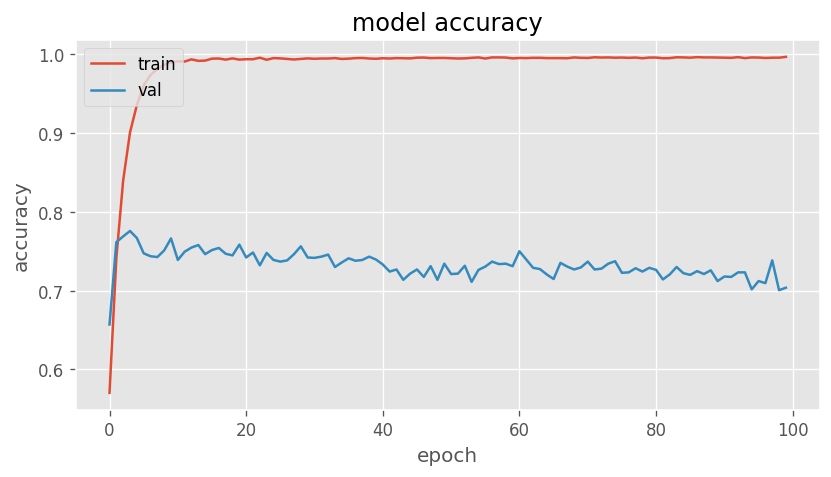

In [63]:
# Plot the accuracy from the model

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

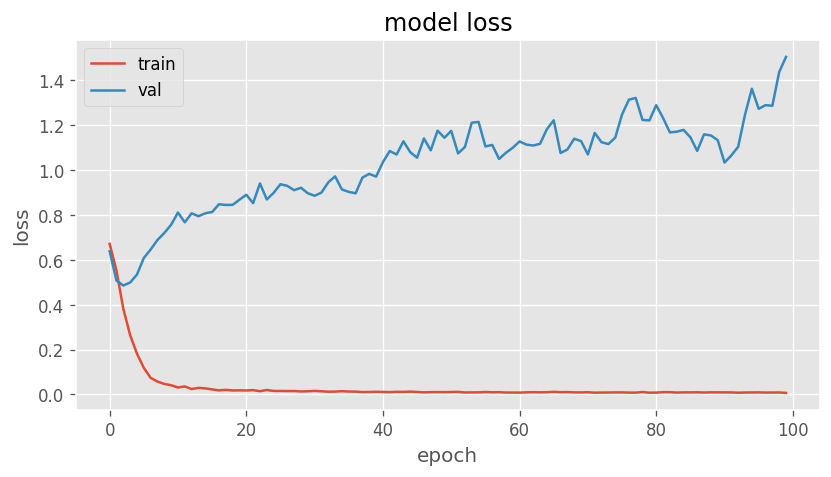

In [64]:
# Plot the loss from the model

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [65]:
# Get the predicted data
# argument "x" needs to be passed in as a list
def get_encoded(x):
    x = token.texts_to_sequences(x)
    x = pad_sequences(x, maxlen=max_length, padding='post')
    return x

In [66]:
x = ['i am thrilled to see this']
vec = get_encoded(x)

In [67]:
# the result comes out as 0, meaning that the text is not disaster related
np.argmax(model.predict(vec), axis=-1)

1/1 [==============================] - 0s 365ms/step


array([0], dtype=int64)

## BERT Model

### Building and training and bert model

In [68]:
# Drop the vec column created previously
tweet.drop(columns='vec', inplace = True)

In [69]:
tweet.head(2)

,id,keyword,location,text,target,char_count,word_count,avg_word_length,stop_word_count
0,1,NaN,NaN,our deeds are the reason of this earthquake may allah forgive us all,1,69,13,4.071429,5
1,4,NaN,NaN,forest fire near la ronge sask canada,1,38,7,4.000000,0


In [70]:
# Import ktrain
from ktrain import text
import ktrain

C:\Users\User\anaconda3\envs\tflowenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [95]:
# Load text data from the dataframe, target data, set tokenization max length of 40, if less than 40 then padding will be applied, preprocessing set to bert
# leave val_data as default (none). texts_from_df will automatically take 10% as validation data
# Returns two tuples, training data and test data, along with a preproc
(X_train, y_train), (X_test, y_test), preproc = text.texts_from_df(train_df=tweet, text_column='text', label_columns='target', maxlen=40, preprocess_mode='bert')

['not_target', 'target']
      not_target  target
7006         1.0     0.0
4862         0.0     1.0
3677         1.0     0.0
2485         1.0     0.0
2237         1.0     0.0
['not_target', 'target']
      not_target  target
6752         0.0     1.0
956          1.0     0.0
1361         0.0     1.0
7036         0.0     1.0
7232         0.0     1.0
preprocessing train...
language: en


Is Multi-Label? False
preprocessing test...
language: en


In [96]:
# Get the model 
model = text.text_classifier(name='bert', train_data=(X_train, y_train), preproc = preproc)

Is Multi-Label? False
maxlen is 40


C:\Users\User\anaconda3\envs\tflowenv\lib\site-packages\keras\initializers\initializers_v2.py:120: UserWarning: The initializer GlorotNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


done.


In [97]:
# get_learner returns a learner instance that can be used to train and tune the model
learner = ktrain.get_learner(model=model, train_data=(X_train, y_train), val_data=(X_test, y_test), batch_size=64)

simulating training for different learning rates... this may take a few moments...
Epoch 1/50
108/108 [==============================] - 1555s 14s/step - loss: 0.8721 - accuracy: 0.4286
Epoch 2/50
108/108 [==============================] - 1519s 14s/step - loss: 0.7570 - accuracy: 0.4423
Epoch 3/50
108/108 [==============================] - 1465s 14s/step - loss: 0.6883 - accuracy: 0.5509
Epoch 4/50
108/108 [==============================] - 1462s 14s/step - loss: 0.6468 - accuracy: 0.6634
Epoch 5/50
108/108 [==============================] - 1464s 14s/step - loss: 0.5959 - accuracy: 0.7214
Epoch 6/50
108/108 [==============================] - 1465s 14s/step - loss: 0.5260 - accuracy: 0.7619
Epoch 7/50
108/108 [==============================] - 1463s 14s/step - loss: 0.4733 - accuracy: 0.7935
Epoch 8/50
108/108 [==============================] - 1475s 14s/step - loss: 0.4274 - accuracy: 0.8187
Epoch 9/50
108/108 [==============================] - 1461s 14s/step - loss: 0.3973 - accurac

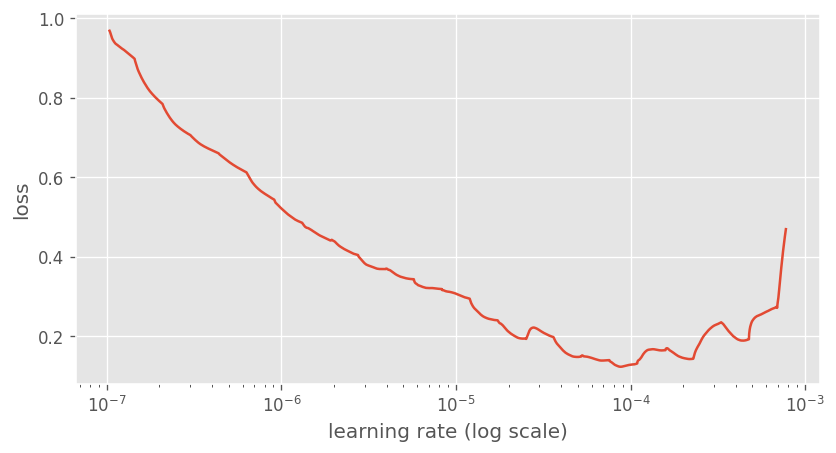

In [97]:
# Obtain a good learning rate
# Set max epochs to it doesn't take too long
learner.lr_find(max_epochs=50)             # briefly simulate training to find good learning rate
learner.lr_plot()             # visually identify best learning rate

In [99]:
# Fit the model with a learning rate of about 8e-4 as this has the lowest error according to the chart above
learner.fit_onecycle(lr = 8e-4, epochs=1)



begin training using onecycle policy with max lr of 0.0008...
108/108 [==============================] - 1258s 12s/step - loss: 0.6315 - accuracy: 0.6434 - val_loss: 0.6781 - val_accuracy: 0.5866


In [100]:
# Get the predictor
predictor = ktrain.get_predictor(learner.model, preproc)

In [101]:
# Test the model
data = ['I met you today by accident', 'I was in a car accident today']

In [102]:
# Predict on the unseen data and get the probability
predictor.predict(data, return_proba = True)

array([[0.5921555 , 0.40784442],
       [0.5921555 , 0.40784445]], dtype=float32)

In [104]:
# The model returns 'not target' for the first data point. This means not a disaster
predictor.predict(data[0])

'not_target'

In [105]:
classes = predictor.get_classes()

In [107]:
# Get the index. 0 means not target (no disaster). 1 means target (disaster)
y_pred = predictor.predict(data[0])
classes.index(y_pred)

0